In [43]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def make_uncontrolled_bp_dataset(n=2000, seed=42):
    rng = np.random.default_rng(seed)

    age_group = rng.choice(["18-34","35-49","50-64","65+"], size=n, p=[0.30,0.25,0.25,0.20])
    sex = rng.choice(["Female","Male"], size=n, p=[0.52,0.48])
    bmi_category = rng.choice(["Normal","Overweight","Obese"], size=n, p=[0.30,0.35,0.35])
    smoker = rng.choice(["No","Yes"], size=n, p=[0.80,0.20])
    diabetes = rng.choice(["No","Yes"], size=n, p=[0.85,0.15])

    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    age_effect = pd.Series(age_group).map({"18-34":0.0,"35-49":0.4,"50-64":0.8,"65+":1.2}).to_numpy()
    bmi_effect = pd.Series(bmi_category).map({"Normal":0.0,"Overweight":0.3,"Obese":0.7}).to_numpy()
    smoker_effect = pd.Series(smoker).map({"No":0.0,"Yes":0.25}).to_numpy()
    diabetes_effect = pd.Series(diabetes).map({"No":0.0,"Yes":0.9}).to_numpy()

    intercept = -1.2
    risk_score = intercept + age_effect + bmi_effect + smoker_effect + diabetes_effect
    p_uncontrolled = sigmoid(risk_score)

    uncontrolled_bp = np.where(rng.random(n) < p_uncontrolled, "Yes", "No")

    return pd.DataFrame({
        "uncontrolled_bp": uncontrolled_bp,
        "age_group": age_group,
        "sex": sex,
        "bmi_category": bmi_category,
        "smoker": smoker,
        "diabetes": diabetes
    })

df = make_uncontrolled_bp_dataset(n=5000, seed=7)
df.head()

,uncontrolled_bp,age_group,sex,bmi_category,smoker,diabetes
0,No,50-64,Male,Overweight,No,No
1,Yes,65+,Male,Obese,No,Yes
2,Yes,50-64,Male,Obese,No,No
3,No,18-34,Female,Overweight,No,No
4,No,35-49,Male,Normal,No,No


In [44]:
df["uncontrolled_bp"].value_counts(normalize=True)

uncontrolled_bp
No     0.5348
Yes    0.4652
Name: proportion, dtype: float64

In [45]:
df.shape

(5000, 6)

In [46]:
pd.crosstab(df["age_group"], df["uncontrolled_bp"], normalize="index")

uncontrolled_bp,No,Yes
age_group,,
18-34,0.660390,0.339610
35-49,0.555288,0.444712
50-64,0.497061,0.502939
65+,0.364349,0.635651


In [47]:
# Mapping the No and Yesses to 1s and 0s to use
df["uncontrolled_bp"] = df["uncontrolled_bp"].map({"No": 0, "Yes": 1})

In [48]:
# Using logistic regression
formula = "uncontrolled_bp ~ C(diabetes) + C(age_group) + C(bmi_category) + C(smoker) + C(sex)"
model = smf.logit(formula, data=df).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.641422
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        uncontrolled_bp   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4991
Method:                           MLE   Df Model:                            8
Date:                Sun, 04 Jan 2026   Pseudo R-squ.:                 0.07138
Time:                        20:41:20   Log-Likelihood:                -3207.1
converged:                       True   LL-Null:                       -3453.6
Covariance Type:            nonrobust   LLR p-value:                2.216e-101
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -1.3258      0.083    -16.053      0.000      -1.488      -1.164
C(diabetes)[T.Yes]                0.9340      0.084     11.165      0.000       0.770       1.098
C(age_group)[T.35-49]             0.4602      0.081      5.702      0.000       0.302       0.618
C(age_group)[T.50-64]             0.7105      0.081      8.729      0.000       0.551       0.870
C(age_group)[T.65+]               1.2669      0.087     14.586      0.000       1.097       1.437
C(bmi_category)[T.Obese]          0.8406      0.075     11.209      0.000       0.694       0.988
C(bmi_category)[T.Overweight]     0.3693      0.076      4.888      0.000       0.221       0.517
C(smoker)[T.Yes]                  0.2330      0.074      3.163      0.002       0.089       0.377
C(sex)[T.Male]                    0.0189      0.060      0.317      0.751      -0.098       0.136
=================================================================================================
"""

In [49]:
odds_ratios = np.exp(model.params)
ci_or = np.exp(model.conf_int())
ci_or.columns = ["OR 2.5%", "OR 97.5%"]

results_table = pd.concat([odds_ratios, ci_or], axis = 1)
results_table.columns = ["Odds Ratio", "OR 2.5%", "OR 97.5%"]
results_table

,Odds Ratio,OR 2.5%,OR 97.5%
Intercept,0.265585,0.225893,0.312252
C(diabetes)[T.Yes],2.544697,2.159875,2.998083
C(age_group)[T.35-49],1.584360,1.352551,1.855897
C(age_group)[T.50-64],2.035061,1.734955,2.387079
C(age_group)[T.65+],3.549684,2.994034,4.208454
C(bmi_category)[T.Obese],2.317743,2.000925,2.684724
C(bmi_category)[T.Overweight],1.446660,1.247558,1.677537
C(smoker)[T.Yes],1.262407,1.092659,1.458525
C(sex)[T.Male],1.019082,0.906644,1.145466


In [50]:
results_no_intercept = results_table.drop(index = "Intercept")
results_no_intercept

,Odds Ratio,OR 2.5%,OR 97.5%
C(diabetes)[T.Yes],2.544697,2.159875,2.998083
C(age_group)[T.35-49],1.584360,1.352551,1.855897
C(age_group)[T.50-64],2.035061,1.734955,2.387079
C(age_group)[T.65+],3.549684,2.994034,4.208454
C(bmi_category)[T.Obese],2.317743,2.000925,2.684724
C(bmi_category)[T.Overweight],1.446660,1.247558,1.677537
C(smoker)[T.Yes],1.262407,1.092659,1.458525
C(sex)[T.Male],1.019082,0.906644,1.145466


In [51]:
label_map = {
    "C(diabetes)[T.Yes]": "Diabetes (Yes vs No)",
    "C(age_group)[T.35-49]": "Age 35–49 vs 18–34",
    "C(age_group)[T.50-64]": "Age 50–64 vs 18–34",
    "C(age_group)[T.65+]": "Age 65+ vs 18–34",
    "C(bmi_category)[T.Overweight]": "Overweight vs Normal BMI",
    "C(bmi_category)[T.Obese]": "Obese vs Normal BMI",
    "C(smoker)[T.Yes]": "Smoker vs Non-smoker",
    "C(sex)[T.Male]": "Male vs Female"
}

results_no_intercept.index = results_no_intercept.index.map(label_map)
results_no_intercept


,Odds Ratio,OR 2.5%,OR 97.5%
Diabetes (Yes vs No),2.544697,2.159875,2.998083
Age 35–49 vs 18–34,1.584360,1.352551,1.855897
Age 50–64 vs 18–34,2.035061,1.734955,2.387079
Age 65+ vs 18–34,3.549684,2.994034,4.208454
Obese vs Normal BMI,2.317743,2.000925,2.684724
Overweight vs Normal BMI,1.446660,1.247558,1.677537
Smoker vs Non-smoker,1.262407,1.092659,1.458525
Male vs Female,1.019082,0.906644,1.145466


In [52]:
#Creating a Forest Plot for Logistic Regression Odds Ratios
plot_df = results_no_intercept.sort_values("Odds Ratio")
plot_df.head()

,Odds Ratio,OR 2.5%,OR 97.5%
Male vs Female,1.019082,0.906644,1.145466
Smoker vs Non-smoker,1.262407,1.092659,1.458525
Overweight vs Normal BMI,1.446660,1.247558,1.677537
Age 35–49 vs 18–34,1.584360,1.352551,1.855897
Age 50–64 vs 18–34,2.035061,1.734955,2.387079


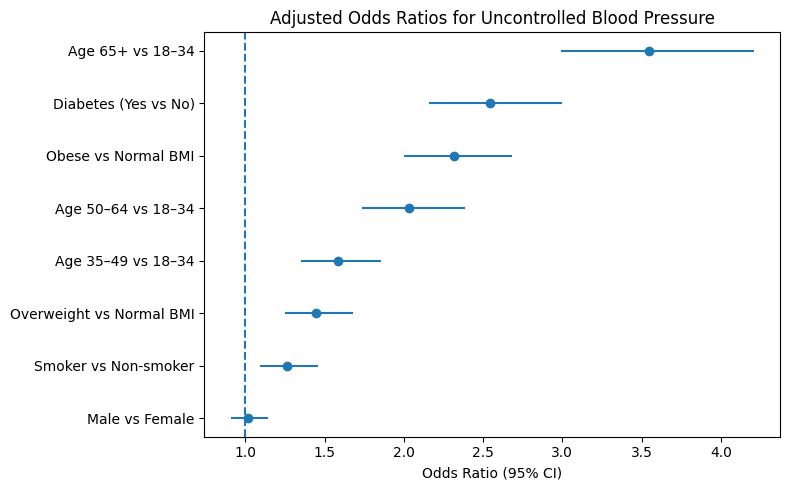

In [53]:
import matplotlib.pyplot as plt

y_pos = range(len(plot_df))

plt.figure(figsize=(8,5))

plt.hlines(y=y_pos, xmin=plot_df["OR 2.5%"], xmax=plot_df["OR 97.5%"])

plt.plot(plot_df["Odds Ratio"], y_pos, "o")

plt.axvline(1, linestyle = "--")

plt.yticks(y_pos, plot_df.index)
plt.xlabel("Odds Ratio (95% CI)")
plt.title("Adjusted Odds Ratios for Uncontrolled Blood Pressure")

plt.tight_layout()
plt.show()